In [30]:
from __future__ import annotations

import cv2
import glob
import logging
import numpy as np
import os
import pandas as pd
import psutil
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

import h5py
import tifffile
import json
import re
import sys
import time
import warnings
from pathlib import Path
from typing import Optional
import skimage.transform

try:
    cv2.setNumThreads(0)
except:
    pass

import caiman as cm
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import cnmf, params
from caiman.summary_images import local_correlations_movie_offline
from caiman.utils.utils import download_demo
from caiman.utils.visualization import plot_contours, nb_view_patches, nb_plot_contour
from caiman.utils.visualization import nb_view_quilt
from caiman.base.movies import play_movie

In [31]:
class Config:
    # Output
    run_name: str = "run1"                       # Output folder name under results/
    configfile: Optional[str] = None              # Set below, defaults to SCRIPT_DIR/params.json
    no_play: bool = False                         # If True, skip interactive display/plots
    cluster_backend: str = "multiprocessing"       # "multiprocessing", "ipyparallel", or "single"
    n_workers: Optional[int] = None                # None = auto
    logfile: Optional[str] = None                  # Set below, defaults to SCRIPT_DIR/recent_logs.txt

    # Data sources
    data_dir: Path = Path("/home/abl-dell/Downloads/caiman_dataset/2026-04-20_145544-20260622T020740Z-3-002/2026-04-20_145544/raw/stack_1-A1-GCaMP8M_channel_1_obj_bottom/")                # REQUIRED: folder for time-split, plane-split

    # Z-plane selection
    z_index: Optional[int] = None                  # Z-plane index (default: middle)
    tune_z: Optional[int] = None                    # Z-plane to tune on for plane-split
    n_planes: Optional[int] = None                  # Number of interleaved Z-planes in a single-movie file

    # Resolution / preprocessing
    resolution: str = "512"                         # "full", "1024", or "512"
    no_stripe: bool = False                          # Disable column-median stripe removal
    max_frames: Optional[int] = None                 # Cap loaded frames at N

    # Format override
    format_override: Optional[str] = None            # "multi-tp","multi-cam","single-movie","interleaved","legacy"

    # Temp files
    keep_tif: bool = False                            # Keep intermediate .tif files after memmap creation
    keep_logs: bool = False                            # Keep temporary logfiles


cfg = Config()

SCRIPT_DIR = Path.cwd()
RESULTS_ROOT = SCRIPT_DIR / "results"

if cfg.configfile is None:
    cfg.configfile = str(SCRIPT_DIR / "params.json")
if cfg.logfile is None:
    cfg.logfile = str(SCRIPT_DIR / "recent_logs.txt")

OUTPUT_DIR = RESULTS_ROOT / cfg.run_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR = OUTPUT_DIR / "_work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print(f"p4_universal (notebook)  |  run={cfg.run_name}")
print("=" * 70)
print(f"Output dir : {OUTPUT_DIR}")
print(f"Resolution : {cfg.resolution}")

if cfg.n_planes:
    _default_z = cfg.z_index if cfg.z_index is not None else cfg.n_planes // 2
    print(f"Z-planes   : {cfg.n_planes} interleaved  (extracting z={_default_z})")

p4_universal (notebook)  |  run=run1
Output dir : /home/abl-dell/Fish_Brain_Dynamics/results/run1
Resolution : 512


In [32]:
def read_n_planes(filepath: str) -> int:
    """Read n_planes from metadata["metaData"]["stack"]["n"] in a .lux*.h5 file; fall back to 1."""
    try:
        with h5py.File(filepath, "r") as fh:
            if "metadata" not in fh:
                return 1
            raw = fh["metadata"][()]
            meta = json.loads(raw)
            return int(meta["metaData"]["stack"]["n"])
    except Exception as e:
        print(f"  WARNING: read_n_planes failed ({e}); defaulting to 1 (treating as single-plane)")
        return 1


def detect_format(folder: Path) -> tuple[str, list[str], tuple]:
    """
    Return (format_name, file_list, sample_shape).

    multi-tp     : many tp-*.lux.h5 files, each (Z, H, W) with Z>1
    multi-cam    : many Cam_long_*.lux*.h5 files, each (1, H, W)
    single-movie : one Cam_long_*.lux*.h5 file with 1 plane (T, H, W)
    interleaved  : one *.lux*.h5 file with Z>1 planes packed into T axis
    legacy       : one .h5 file with (T, H, W)
    """
    folder = Path(folder)

    tp_files = sorted(
        glob.glob(str(folder / "tp-*_ch-*_st-*_obj-*_cam-*.lux.h5")),
        key=lambda p: int(re.search(r"tp-0-(\d+)", p).group(1)),
    )
    if tp_files:
        with h5py.File(tp_files[0], "r") as fh:
            shape = tuple(fh["Data"].shape)
        return "multi-tp", tp_files, shape

    # Broaden glob to catch both *.lux.h5 and *.lux-NNN.h5 naming
    cam_files = sorted(
        glob.glob(str(folder / "Cam_long_*.lux*.h5")),
        key=lambda p: int(re.search(r"Cam_long_(\d+)", p).group(1)),
    )
    if cam_files:
        with h5py.File(cam_files[0], "r") as fh:
            shape = tuple(fh["Data"].shape)
        if len(cam_files) > 1:
            if shape[0] == 1:
                return "multi-cam", cam_files, shape
            return "single-movie", cam_files, shape
        # Single file — check metadata for plane count
        n_z = read_n_planes(cam_files[0])
        if n_z > 1:
            return "interleaved", cam_files, shape
        return "single-movie", cam_files, shape

    # Catch-all for any other *.lux*.h5 files (non-Cam_long naming)
    lux_files = sorted(glob.glob(str(folder / "*.lux*.h5")))
    if lux_files:
        with h5py.File(lux_files[0], "r") as fh:
            if "Data" in fh:
                shape = tuple(fh["Data"].shape)
                n_z = read_n_planes(lux_files[0])
                if n_z > 1:
                    return "interleaved", lux_files, shape
                return "single-movie", lux_files, shape

    h5_files = sorted(glob.glob(str(folder / "*.h5")))
    if h5_files:
        with h5py.File(h5_files[0], "r") as fh:
            keys = list(fh.keys())
            if "Data" in keys:
                shape = tuple(fh["Data"].shape)
                return "legacy", h5_files, shape

    raise FileNotFoundError(f"No recognizable .lux*.h5 / .h5 files in {folder}")


def discover(folder: Path, override: Optional[str] = None,
             n_planes_override: Optional[int] = None
             ) -> tuple[str, list[str], tuple, Optional[int]]:
    """Detect or override format. Print result. Returns (fmt, files, shape, n_planes_detected).

    n_planes_detected is set only for interleaved format when detected from
    metadata; otherwise None. Callers should use a locally-scoped variable
    rather than relying on global cfg.n_planes being populated.
    """
    fmt, files, shape = detect_format(folder)
    if override and override != fmt:
        print(f"  Format override: detected={fmt} -> using={override}")
        fmt = override
    detected_n_planes: Optional[int] = None
    if fmt == "interleaved":
        if n_planes_override is not None:
            detected_n_planes = n_planes_override
        else:
            detected_n_planes = read_n_planes(files[0])
            print(f"  Auto-detected n_planes={detected_n_planes} from metadata")
    print(f"  Folder : {folder}")
    print(f"  Format : {fmt}  ({len(files)} file(s), sample shape={shape})")
    return fmt, files, shape, detected_n_planes

In [33]:
def load_movie(folder: Path, fmt: str, files: list[str], shape: tuple,
               z_index: Optional[int] = None,
               max_frames: Optional[int] = None,
               n_planes: Optional[int] = None) -> np.ndarray:
    """
    Build (T, H, W) float32 movie regardless of source format.

    For multi-tp: pick z_index plane from each timepoint file.
    For multi-cam: each file is one timepoint, use Data[0].
    For interleaved: stride the T axis by n_planes to extract one Z plane.
    For single-movie/legacy: read whole Data array (or chunks if huge).
    """
    if fmt == "interleaved":
        T_full, H, W = shape
        nz = n_planes or 1
        if z_index is None:
            z_index = nz // 2
        if z_index >= nz:
            raise ValueError(f"z_index {z_index} >= n_planes {nz}")
        indices = list(range(z_index, T_full, nz))
        if max_frames:
            indices = indices[:max_frames]
        print(f"  Interleaved: z={z_index}/{nz} planes -> {len(indices)} frames")
        with h5py.File(files[0], "r") as fh:
            data = fh["Data"][indices].astype(np.float32)
        return data

    if fmt == "multi-tp":
        Z, H, W = shape
        if z_index is None:
            z_index = Z // 2
        if z_index >= Z:
            raise ValueError(f"z_index {z_index} >= Z={Z}")
        T = len(files)
        if max_frames:
            T = min(T, max_frames)
            files = files[:T]
        print(f"  Loading {T} timepoints @ z={z_index}...")
        data = np.zeros((T, H, W), dtype=np.float32)
        for i, fp in enumerate(files):
            with h5py.File(fp, "r") as fh:
                data[i] = fh["Data"][z_index].astype(np.float32)
        return data

    if fmt == "multi-cam":
        _, H, W = shape
        T = len(files)
        if max_frames:
            T = min(T, max_frames)
            files = files[:T]
        print(f"  Loading {T} single-plane files...")
        data = np.zeros((T, H, W), dtype=np.float32)
        for i, fp in enumerate(files):
            with h5py.File(fp, "r") as fh:
                data[i] = fh["Data"][0].astype(np.float32)
        return data

    if fmt in ("single-movie", "legacy"):
        T_full, H, W = shape
        with h5py.File(files[0], "r") as fh:
            if n_planes and n_planes > 1:
                if z_index is None:
                    z_index = n_planes // 2
                if z_index >= n_planes:
                    raise ValueError(f"z_index {z_index} >= n_planes {n_planes}")
                indices = list(range(z_index, T_full, n_planes))
                if max_frames:
                    indices = indices[:max_frames]
                T = len(indices)
                print(f"  Striding {T_full} frames by n_planes={n_planes} (z={z_index}) -> {T} time-points...")
                data = fh["Data"][indices].astype(np.float32)
            else:
                T = T_full if max_frames is None else min(T_full, max_frames)
                print(f"  Loading {T}/{T_full} frames from single file...")
                data = fh["Data"][:T].astype(np.float32)
        return data

    raise ValueError(f"Unknown format: {fmt}")


def load_plane_multi_tp(files: list[str], z_index: int) -> np.ndarray:
    """Load specific z-plane across all multi-tp files. Used by plane-split."""
    with h5py.File(files[0], "r") as fh:
        Z, H, W = fh["Data"].shape
    if z_index >= Z:
        raise ValueError(f"z_index {z_index} >= Z={Z}")
    T = len(files)
    data = np.zeros((T, H, W), dtype=np.float32)
    for i, fp in enumerate(files):
        with h5py.File(fp, "r") as fh:
            data[i] = fh["Data"][z_index].astype(np.float32)
    return data


def load_plane_interleaved(filepath: str, z_index: int, n_planes: int) -> np.ndarray:
    """Load one Z plane from an interleaved single file by striding the T axis."""
    with h5py.File(filepath, "r") as fh:
        T_full, H, W = fh["Data"].shape
        if z_index >= n_planes:
            raise ValueError(f"z_index {z_index} >= n_planes {n_planes}")
        indices = list(range(z_index, T_full, n_planes))
        return fh["Data"][indices].astype(np.float32)

In [34]:
def downsample(data: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    """Resize each frame with anti-aliasing."""
    T = data.shape[0]
    out = np.zeros((T, target_h, target_w), dtype=np.float32)
    for t in range(T):
        out[t] = skimage.transform.resize(
            data[t], (target_h, target_w), anti_aliasing=True,
        )
    return out


def stripe_remove(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Subtract per-column temporal+row median (light-sheet stripe artifact)."""
    col_median = np.median(data, axis=(0, 2), keepdims=True)
    cleaned = np.clip(data - col_median, 0, None).astype(np.float32)
    return cleaned, col_median


def preprocess_movie(data: np.ndarray, label: str = "") -> tuple[np.ndarray, dict]:
    """
    Full preprocessing pipeline.
    Returns (preprocessed_movie, preprocessing_info)
    """
    info = {"original_shape": tuple(data.shape)}
    print(f"\n[preprocess {label}]  input shape={data.shape}")

    # Resolution
    if cfg.resolution == "512":
        target = (512, 512)
    elif cfg.resolution == "1024":
        target = (1024, 1024)
    else:
        target = data.shape[1:]

    if data.shape[1:] != target:
        print(f"  Downsampling -> {target}")
        data = downsample(data, *target)
        info["downsampled_to"] = target

    # Stripe removal
    if not cfg.no_stripe:
        data, col_median = stripe_remove(data)
        info["stripe_removed"] = True
        # Save stripe plot
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].imshow(data[data.shape[0] // 2], cmap="gray")
        axes[0].set_title(f"Frame {data.shape[0]//2} after stripe removal")
        axes[0].axis("off")
        axes[1].imshow(col_median.reshape(1, -1), cmap="gray", aspect="auto")
        axes[1].set_title("Removed stripe pattern")
        axes[1].set_xlabel("Column index")
        plt.tight_layout()
        plt.savefig(str(OUTPUT_DIR / f"preprocess_{label or 'main'}.png"), dpi=100)
        plt.show()
    else:
        info["stripe_removed"] = False

    info["final_shape"] = tuple(data.shape)
    return data, info

In [35]:
print(f"\nSETTING UP LOGGING...")

# Set up logging
logger = logging.getLogger("caiman")
logger.setLevel(logging.INFO)  # Or another loglevel
logfmt = logging.Formatter("[%(filename)s:%(funcName)20s():%(lineno)s] %(message)s")

if cfg.logfile:
    handler = logging.FileHandler(cfg.logfile)
else:
    handler = logging.StreamHandler()

handler.setFormatter(logfmt)
logger.addHandler(handler)

# First set up some parameters for data and motion correction
opts = params.CNMFParams(params_from_file=cfg.configfile)


SETTING UP LOGGING...


In [36]:
fmt, files, sample_shape, _nplanes = discover(cfg.data_dir, cfg.format_override)
z_index = cfg.z_index

if fmt == "multi-tp":
    Z = sample_shape[0]
    z_index = Z // 2 if z_index is None else z_index
elif fmt == "interleaved" and z_index is None:
    z_index = (_nplanes if _nplanes is not None else cfg.n_planes) // 2
elif cfg.n_planes and z_index is None:
    z_index = cfg.n_planes // 2

raw = load_movie(cfg.data_dir, fmt, files, sample_shape,
                 z_index=z_index, max_frames=cfg.max_frames,
                 n_planes=_nplanes if _nplanes is not None else cfg.n_planes)

  Auto-detected n_planes=7 from metadata
  Folder : /home/abl-dell/Downloads/caiman_dataset/2026-04-20_145544-20260622T020740Z-3-002/2026-04-20_145544/raw/stack_1-A1-GCaMP8M_channel_1_obj_bottom
  Format : interleaved  (1 file(s), sample shape=(4900, 2048, 2048))
  Interleaved: z=3/7 planes -> 700 frames



[preprocess movie]  input shape=(700, 2048, 2048)
  Downsampling -> (512, 512)


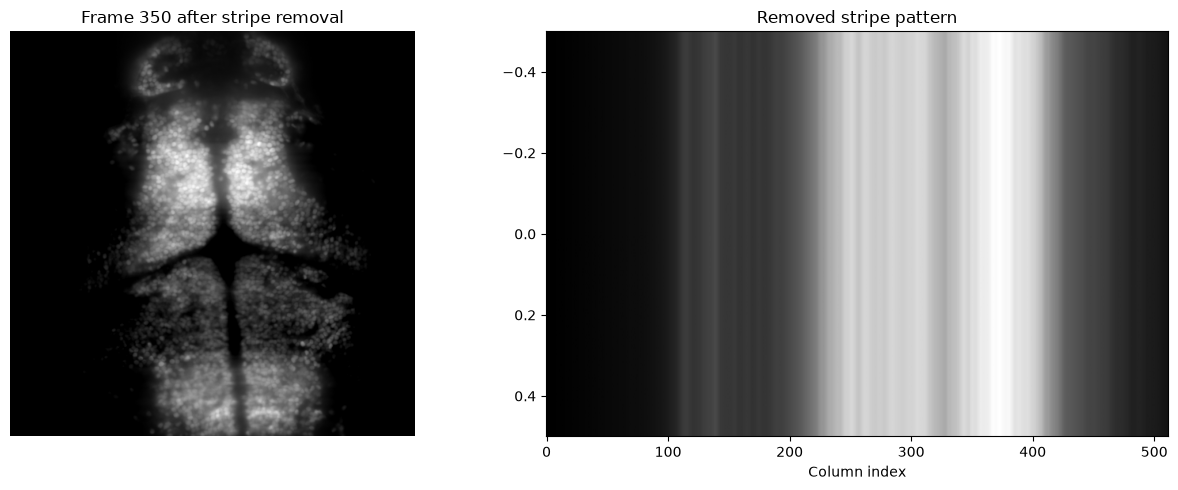

'/home/abl-dell/Fish_Brain_Dynamics/results/run1/_work/session1_preprocessed.tif'

In [37]:
data, prep_info = preprocess_movie(raw, label="movie")

fname_pp = str(WORK_DIR / "session1_preprocessed.tif")

m_orig = cm.movie(data, fr=opts.data['fr'])
m_orig.save(fname_pp)

In [38]:
if not cfg.no_play:
    ds_ratio = 0.2
    moviehandle = m_orig.resize(fz=ds_ratio)
    m_orig.play(
        gain=1.3,
        q_max=99.5,
        fr=30,
        magnification=1,
        backend='opencv',
        do_loop=True)

# Start Cluster

In [39]:
_, cluster, n_processes = cm.cluster.setup_cluster(
    backend=cfg.cluster_backend, n_processes=cfg.n_workers, ignore_preexisting=False)
print(f"Successfully initialized multicore processing with a pool of {n_processes} CPU cores")

Successfully initialized multicore processing with a pool of 95 CPU cores


# Motion Correction

In [40]:
# first we create a motion correction object with the specified parameters
mc = MotionCorrect([fname_pp], dview=cluster, **opts.get_group('motion'))
# note that the file is not loaded in memory

# Run (piecewise-rigid motion) correction using NoRMCorre
mc.motion_correct(save_movie=True)

In [41]:
if not cfg.no_play:
    movie_corrected = cm.load(mc.mmap_file)
    ds_ratio = 0.2
    moviehandle = cm.concatenate(
        [m_orig.resize(1, 1, ds_ratio) - mc.min_mov * mc.nonneg_movie,
         movie_corrected.resize(1, 1, ds_ratio)], axis=2)
    moviehandle.play(fr=20, q_max=99.5, magnification=2, gain=2, do_loop=True)  # press q to exit

100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


In [ ]:
border_to_0 = 0 if mc.border_nan == 'copy' else mc.border_to_0
# you can include the boundaries of the FOV if you used the 'copy' option
# during motion correction, although be careful about the components near
# the boundaries

# memory map the file in order 'C'
fname_new = cm.save_memmap(mc.mmap_file, base_name='memmap_', order='C',
                           border_to_0=border_to_0, dview=cluster)  # exclude borders

# now load the file
Yr, dims, num_frames = cm.load_memmap(fname_new)
images = np.reshape(Yr.T, [num_frames] + list(dims), order='F')
# load frames in python format (T x X x Y)

# restart cluster to clean up memory
cm.stop_server(dview=cluster)
_, cluster, n_processes = cm.cluster.setup_cluster(
    backend=cfg.cluster_backend, n_processes=cfg.n_workers, single_thread=False)

/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer
/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer
/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer
/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/scipy/ndimage/_measurements.py:1550: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum_labels(input * grids[dir].astype(float), labels, index) / normalizer
/hom

In [43]:
# opts.change_params({'p': 0})
cnmf_model = cnmf.CNMF(n_processes, params=opts, dview=cluster)
cnmf_model.fit(images)

/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/caiman/source_extraction/cnmf/merging.py:154: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_values = [scipy.stats.pearsonr(C[ii, :], C[jj, :])[


In [44]:
window = min(1000, num_frames)
stride = min(1000, num_frames)
winSize_baseline = min(100, num_frames // 2)

Cns = local_correlations_movie_offline(mc.mmap_file[0],
                                    remove_baseline=True,
                                    window=window,
                                    stride=stride,
                                    winSize_baseline=winSize_baseline,
                                    quantil_min_baseline=10,
                                    dview=cluster)

Cn = Cns.max(axis=0)  # max projection
Cn[np.isnan(Cn)] = 0  # get rid of NaNs, if they exist

if not cfg.no_play:
    cnmf_model.estimates.plot_contours_nb(img=Cn)


# save results
cnmf_model.estimates.Cn = Cn
cnmf_model.save(fname_new[:-5] + '_init.hdf5')

In [45]:
cnmf_refit = cnmf_model.refit(images, dview=cluster)

if cnmf_refit.estimates.dims is None:
    cnmf_refit.estimates.dims = images.shape[1:]  # (H, W) i.e. (512, 512)

# Component Evaluation

In [46]:
cnmf_refit.estimates.evaluate_components(images, cnmf_refit.params, dview=cluster)

print(f"Num accepted/rejected: {len(cnmf_refit.estimates.idx_components)}, "
      f"{len(cnmf_refit.estimates.idx_components_bad)}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Num accepted/rejected: 51, 195


# Plot accepted components

In [47]:
if not cfg.no_play:
    # Plot Components
    cnmf_refit.estimates.plot_contours_nb(img=Cn, idx=cnmf_refit.estimates.idx_components)


    cnmf_refit.estimates.nb_view_components(images, img=Cn,
                                        idx=cnmf_refit.estimates.idx_components, cmap='gray',
                                            denoised_color='red')

# Select components and extract dF/F

In [51]:
if cnmf_refit.estimates.F_dff is None:
    print('Calculating estimates.F_dff')
    cnmf_refit.estimates.detrend_df_f(quantileMin=8, 
                                      frames_window=250,
                                      flag_auto=False,
                                      use_residuals=False);  
else:
    print("estimates.F_dff already defined")

Calculating estimates.F_dff


In [52]:
frame_rate = cnmf_refit.params.data['fr']
frame_pd = 1/frame_rate
frame_times = np.linspace(0, num_frames*frame_pd, num_frames);

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3033491/1073546947.py:11: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta F/F$')
/tmp/ipykernel_3033491/1073546947.py:12: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta F/F$ for unit {component_number}");


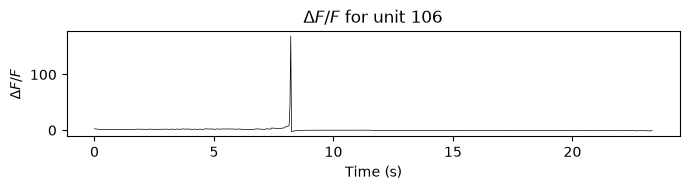

In [53]:
# plot F_dff
idx_to_plot = 14
idx_accepted = cnmf_refit.estimates.idx_components
component_number = idx_accepted[idx_to_plot]
f, ax = plt.subplots(figsize=(7,2))
ax.plot(frame_times, 
        cnmf_refit.estimates.F_dff[component_number, :], 
        linewidth=0.5,
        color='k');
ax.set_xlabel('Time (s)')
ax.set_ylabel('$\Delta F/F$')
ax.set_title(f"$\Delta F/F$ for unit {component_number}");
plt.tight_layout()

In [55]:
max_projection = np.max(movie_corrected, axis=0)
correlation_image = cm.local_correlations(movie_corrected, swap_dim=False)
correlation_image[np.isnan(correlation_image)] = 0 # get rid of NaNs, if they exist

/home/abl-dell/miniforge3/envs/caiman/lib/python3.12/site-packages/caiman/summary_images.py:210: RuntimeWarning: invalid value encountered in divide
  w_mov = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)


In [56]:
# update object with selected components (optional)
cnmf_refit.estimates.select_components(use_object=True)

cnmf_refit.estimates.nb_view_components(img=correlation_image, 
                                        denoised_color='red',
                                        cmap='gray');
cnmf_refit.estimates.Cn = Cn

cnmf_refit.save(fname_new[:-5] + '_refit.hdf5')

# Play reconstructed denoised movie

In [57]:
# reconstruct denoised movie
neural_activity = cnmf_refit.estimates.A @ cnmf_refit.estimates.C  # AC
background = cnmf_refit.estimates.b @ cnmf_refit.estimates.f  # bf
denoised_movie = neural_activity + background  # AC + bf

# turn into a movie object
denoised_movie = cm.movie(denoised_movie).reshape(dims + (-1,), order='F').transpose([2, 0, 1])

In [58]:
# press q to quit
downsampling_rate = 0.2
denoised_movie = denoised_movie.resize(fz=downsampling_rate)

denoised_movie.play(gain=0.8,
                    q_min=30,
                    q_max=99, 
                    fr=30,
                    plot_text=True,
                    magnification=3,
                    backend='opencv')

error: OpenCV(5.0.0) /home/conda/feedstock_root/build_artifacts/libopencv_1782348275014/work/modules/imgproc/src/drawing_text.cpp:1430: error: (-215:Assertion failed) img.depth() == CV_8U in function 'putText'


In [ ]:
if not cfg.no_play:
    cnmf_refit.estimates.play_movie(images, q_max=99.9, gain_res=2,
                              magnification=2,
                              bpx=border_to_0,
                              include_bck=False)  # background not shown

# Cleanup

In [ ]:
# Stop the cluster and clean up log files
cm.stop_server(dview=cluster)
if not cfg.no_play:
    matplotlib.pyplot.show(block=True)

logging_dir = cm.paths.get_tempdir()

if not cfg.keep_logs:
    log_files = glob.glob('*_LOG_*')
    for log_file in log_files:
        print(f"Deleting {log_file}")
        os.remove(log_file)
else:
    print(f"If you want to inspect your logs they are in {logging_dir}")

print(f"\n{'='*70}")
print(f"DONE  |  {cfg.run_name}")
print(f"{'='*70}")


DONE  |  run1
